# _Drake vs Kendrick Rhyme Scheme Analysis_
How does lyrical complexity, measured through rhyme density and lyrical complexity, relate to popularity and listener engagement in hip-hop?
Specifically, how do these patterns differ between two of the genre’s most influential artists, Kendrick Lamar and Drake, across their careers?

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from collections import Counter
import nltk
from nltk.corpus import cmudict
from collections import Counter
nltk.download("cmudict") # dictionary for rhyme scheme analysis
from dotenv import load_dotenv
import lyricsgenius as lg
import requests
import spacy
import re
import time
import sqlite3
nlp=spacy.load("en_core_web_sm")

[nltk_data] Downloading package cmudict to
[nltk_data]     /Users/mattabatangle/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


In [2]:
load_dotenv("3510.env")

True

# Test to make sure stuff is working

In [3]:
geniusClientAccess = os.getenv("GENIUS_CLIENT_ACCESS_TOKEN")
clientID = os.getenv("SPOTIFY_CLIENT_ID")
genius = lg.Genius(geniusClientAccess)
genius.remove_section_headers = True

In [4]:
temp = genius.search_artist("Kendrick Lamar", max_songs=5) # test

Searching for songs by Kendrick Lamar...

Song 1: "Not Like Us"
Song 2: "HUMBLE."
Song 3: "euphoria"
Song 4: "m.A.A.d city"
Song 5: "Swimming Pools (Drank)"

Reached user-specified song limit (5).
Done. Found 5 songs.


In [5]:
genius.search_artist("Drake", max_songs=5) # test

Searching for songs by Drake...

Song 1: "God’s Plan"
Song 2: "In My Feelings"
Song 3: "Hotline Bling"
Song 4: "One Dance"
Song 5: "Hold On, We’re Going Home"

Reached user-specified song limit (5).
Done. Found 5 songs.


Artist(name=Drake, num_songs=5)

In [6]:
clientID = os.getenv("SPOTIFY_CLIENT_ID")
clientSecret = os.getenv("SPOTIFY_CLIENT_SECRET")
grantType = 'client_credentials'
bodyParams = {"grant_type": grantType}
url = 'https://accounts.spotify.com/api/token'
responseJSON = requests.post(url, data=bodyParams, auth=(clientID, clientSecret)).json()
headers = {"Authorization": "Bearer "+responseJSON['access_token']}
rootURL = 'https://api.spotify.com/v1/'

Gathering each artists unique ID will make things easier when scraping their entire catelogs.

In [7]:
kendrickSearch = requests.get(rootURL+"search?q=Kendrick-Lamar&type=artist",headers=headers).json()

In [8]:
kendrickID = kendrickSearch['artists']['items'][0]['id']

In [9]:
drakeSearch = requests.get(rootURL+"search?q=Drake&type=artist",headers=headers).json()

In [10]:
drakeID = drakeSearch['artists']['items'][0]['id']

# Now lets get started

First, I will scrape every available song from the Spotify API for both artists. This will make it easy to then pull 30-40 indivudal songs that will give an accurate representation of each artists discography over time.

In [11]:
def get_all_albums_and_singles(artist_id, include_groups=("album", "single"), market="US"):
    albums = [] # list to hold
    params = {"limit":50, "include_groups": ",".join(include_groups), "market": market} # Limit to 50 albums (Neither artists have more than 50)
    url = rootURL+f"artists/{artist_id}/albums" # base url
    while url:
        albumSearch = requests.get(url, headers=headers, params=params)
        if albumSearch.status_code != 200: # Troubleshoot
            print(f"Error: {albumSearch.status_code} for {url}")
            break
        data = albumSearch.json()
        albums.extend(data["items"]) # Extend instead of append to add multiple items
        url = data["next"] # Iterate
    
        params = None # Params already set as of here
    return albums

In [12]:
kendrickAlbumsSingles = get_all_albums_and_singles(kendrickID)
drakeAlbumsSingles = get_all_albums_and_singles(drakeID)

In [13]:
def get_album_tracks(album_id):
    tracks = []
    url = f"{rootURL}albums/{album_id}/tracks" # base url
    params = {"limit": 50, "market": "US"} # reasonable limit of 50 songs per album

    while url:
        trackReq = requests.get(url, headers=headers, params=params)
        if trackReq.status_code != 200: # Troubleshoot
            print(f"Error {trackReq.status_code} fetching tracks for album {album_id}")
            break
        data = trackReq.json()
        tracks.extend(data["items"]) # Extend instead of append to add multiple items
        url = data["next"] # Iterate
        params = None # Params already set as of here
    return tracks

# Next I will iterate through each artists albums and gather track data

In [14]:
rows = []
for album in kendrickAlbumsSingles:
    albumID = album["id"]
    albumName = album["name"]
    releaseDate = album["release_date"]
    albumType = album["album_group"] or album["album_type"]

    tracks = get_album_tracks(albumID)
    
    for t in tracks:
        if not any(a["id"] == kendrickID for a in t["artists"]):
            continue
        rows.append({
            "artist": "Kendrick Lamar",
            "artist_id": kendrickID,
            "album_id": albumID,
            "album_name": albumName,
            "album_type": albumType,
            "release_date": releaseDate,
            "track_id": t["id"],
            "track_name": t["name"],
            "duration_ms": t["duration_ms"],
            "track_number": t["track_number"],
            "disc_number": t["disc_number"],
            "explicit": t.get("explicit", False),
        })

In [15]:
kendrickTracksUnfiltered = pd.DataFrame(rows)
kendrickTracksUnfiltered

,artist,artist_id,album_id,album_name,album_type,release_date,track_id,track_name,duration_ms,track_number,disc_number,explicit
0,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,5gOfC9UzZQzTyShqPMrpjT,wacced out murals,317092,1,1,True
1,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,0nj9Bq5sHDiTxSHunhgkFb,squabble up,157992,2,1,True
2,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,45J4avUb9Ni0bnETYaYFVJ,luther (with sza),177598,3,1,False
3,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,5ho7VSXSmI2KM2nDjcnLyz,man at the garden,233173,4,1,True
4,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,5S8VwnB4sLi6W0lYTWYylu,hey now (feat. dody6),217478,5,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...
166,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,3qHsYfN7ua1WGhQn1wquIn,Push Thru (feat. Kendrick Lamar and Curren$y),single,2012,7HetWRCNDPHhiksK6VrAG1,Push Thru,300800,1,1,True
167,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,3qHsYfN7ua1WGhQn1wquIn,Push Thru (feat. Kendrick Lamar and Curren$y),single,2012,1kDctACNpFgSB7lZXPrazv,Push Thru,301240,2,1,False
168,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,3qHsYfN7ua1WGhQn1wquIn,Push Thru (feat. Kendrick Lamar and Curren$y),single,2012,4M6IrkoE9LQMZzZx8eHNQD,Push Thru - Instrumental,300346,3,1,False
169,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,1Jmy19ydnxfHcOdN28cw7q,"My People (feat. Jay Rock) (""Bastards of the P...",single,2011-08-16,0WkQfxU3podAt3UAenbzPd,"My People (feat. Jay Rock) (""Bastards of the P...",241086,1,1,True


In [16]:
rows = []
for album in drakeAlbumsSingles:
    albumID = album["id"]
    albumName = album["name"]
    releaseDate = album["release_date"]
    albumType = album["album_group"] or album["album_type"]

    tracks = get_album_tracks(albumID)
    
    for t in tracks:
        # Skip tracks where artist isn't primary
        if not any(a["id"] == drakeID for a in t["artists"]):
            continue
        rows.append({
            "artist": "Drake",
            "artist_id": drakeID,
            "album_id": albumID,
            "album_name": albumName,
            "album_type": albumType,
            "release_date": releaseDate,
            "track_id": t["id"],
            "track_name": t["name"],
            "duration_ms": t["duration_ms"],
            "track_number": t["track_number"],
            "disc_number": t["disc_number"],
            "explicit": t.get("explicit", False) # default false
        })

In [17]:
drakeTracksUnfiltered = pd.DataFrame(rows)
drakeTracksUnfiltered

,artist,artist_id,album_id,album_name,album_type,release_date,track_id,track_name,duration_ms,track_number,disc_number,explicit
0,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,4u43I0LP2Xf85OAS85eG0R,CN TOWER,241889,1,1,True
1,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,7DL2F2bueQycqYjqsjHYjG,MOTH BALLS,212629,2,1,True
2,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,1F6nHHDJyTHLgDDFj1ZZDt,SOMETHING ABOUT YOU,218682,3,1,True
3,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,5aIEFCKhVUM5sKkwOSdFiM,CRYING IN CHANEL,199602,4,1,True
4,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,4GqhG9rDuRUoNyDSMJ0Brq,SPIDER-MAN SUPERMAN,203893,5,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...
397,Drake,3TVXtAsR1Inumwj472S9r4,4VVBDjcpEc8vFWMlQfnmHX,Miss Me,single,2010-01-01,3h5boR23744b1CCE54hN3k,Miss Me,305786,1,1,True
398,Drake,3TVXtAsR1Inumwj472S9r4,645FRpimwu0b1isiY5M32J,I'm Goin In,single,2009-09-15,5aooThgj87ID0vgiyvcjPM,I'm Goin In,225306,1,1,True
399,Drake,3TVXtAsR1Inumwj472S9r4,2wmvVAqB2sAiJQpp2pRWcD,Fear,single,2009-09-15,5WfBl43XUcWng7OnB8LKNW,Fear,280666,1,1,True
400,Drake,3TVXtAsR1Inumwj472S9r4,4Z4vthIzd6pIKC396R5vSN,Forever,single,2009-01-01,3qjKqmA2YeH0a8DRoKj8iy,Forever,357920,1,1,True


# Next I want to select songs from each artist (top 20/30 + 10 low-pop)

# There is a small issue though. Popularity score is not avaliable when being called through a /albums/{id}/tracks endpoint. Therefore, we need to access each track through a /tracks/{id} endpoint to get its popularity score and add it to the rows.

In [18]:
def add_popularity(df):
    ids = df["track_id"].dropna().unique().tolist() # Get a unique list of all track IDs
    pops = {}
    for i in range(0, len(ids), 50):  # Spotify lets up to 50 per call
        chunk = ids[i:i+50]  # Spotify API only allows up to 50 IDs per request, so we loop through the list in chunks of 50
        popRequest = requests.get(rootURL + "tracks", headers=headers, params={"ids": ",".join(chunk)}) # Get data for all tracks through API call
        if popRequest.status_code == 200:
            for track in popRequest.json()["tracks"]:
                if track:
                    pops[track["id"]] = track.get("popularity", None) # Account for potential lack of key val
    df["popularity"] = df["track_id"].map(pops) # Map the popularity dictionary back into dataframe
    return df

In [19]:
add_popularity(kendrickTracksUnfiltered)

,artist,artist_id,album_id,album_name,album_type,release_date,track_id,track_name,duration_ms,track_number,disc_number,explicit,popularity
0,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,5gOfC9UzZQzTyShqPMrpjT,wacced out murals,317092,1,1,True,70
1,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,0nj9Bq5sHDiTxSHunhgkFb,squabble up,157992,2,1,True,81
2,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,45J4avUb9Ni0bnETYaYFVJ,luther (with sza),177598,3,1,False,84
3,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,5ho7VSXSmI2KM2nDjcnLyz,man at the garden,233173,4,1,True,67
4,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,5S8VwnB4sLi6W0lYTWYylu,hey now (feat. dody6),217478,5,1,True,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,3qHsYfN7ua1WGhQn1wquIn,Push Thru (feat. Kendrick Lamar and Curren$y),single,2012,7HetWRCNDPHhiksK6VrAG1,Push Thru,300800,1,1,True,27
167,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,3qHsYfN7ua1WGhQn1wquIn,Push Thru (feat. Kendrick Lamar and Curren$y),single,2012,1kDctACNpFgSB7lZXPrazv,Push Thru,301240,2,1,False,16
168,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,3qHsYfN7ua1WGhQn1wquIn,Push Thru (feat. Kendrick Lamar and Curren$y),single,2012,4M6IrkoE9LQMZzZx8eHNQD,Push Thru - Instrumental,300346,3,1,False,16
169,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,1Jmy19ydnxfHcOdN28cw7q,"My People (feat. Jay Rock) (""Bastards of the P...",single,2011-08-16,0WkQfxU3podAt3UAenbzPd,"My People (feat. Jay Rock) (""Bastards of the P...",241086,1,1,True,38


In [20]:
add_popularity(drakeTracksUnfiltered)

,artist,artist_id,album_id,album_name,album_type,release_date,track_id,track_name,duration_ms,track_number,disc_number,explicit,popularity
0,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,4u43I0LP2Xf85OAS85eG0R,CN TOWER,241889,1,1,True,73
1,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,7DL2F2bueQycqYjqsjHYjG,MOTH BALLS,212629,2,1,True,69
2,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,1F6nHHDJyTHLgDDFj1ZZDt,SOMETHING ABOUT YOU,218682,3,1,True,75
3,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,5aIEFCKhVUM5sKkwOSdFiM,CRYING IN CHANEL,199602,4,1,True,65
4,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,4GqhG9rDuRUoNyDSMJ0Brq,SPIDER-MAN SUPERMAN,203893,5,1,True,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,Drake,3TVXtAsR1Inumwj472S9r4,4VVBDjcpEc8vFWMlQfnmHX,Miss Me,single,2010-01-01,3h5boR23744b1CCE54hN3k,Miss Me,305786,1,1,True,34
398,Drake,3TVXtAsR1Inumwj472S9r4,645FRpimwu0b1isiY5M32J,I'm Goin In,single,2009-09-15,5aooThgj87ID0vgiyvcjPM,I'm Goin In,225306,1,1,True,67
399,Drake,3TVXtAsR1Inumwj472S9r4,2wmvVAqB2sAiJQpp2pRWcD,Fear,single,2009-09-15,5WfBl43XUcWng7OnB8LKNW,Fear,280666,1,1,True,58
400,Drake,3TVXtAsR1Inumwj472S9r4,4Z4vthIzd6pIKC396R5vSN,Forever,single,2009-01-01,3qjKqmA2YeH0a8DRoKj8iy,Forever,357920,1,1,True,72


In [21]:
def select_tracks_for_analysis(df, top_n, low_n):
    df = df.dropna(subset=["track_id", "popularity"]).drop_duplicates("track_id")
    top = (df.sort_values("popularity", ascending=False).groupby("album_id", as_index=False).head(5))  # Cap per album to avoid one album dominating
    top = top.sort_values("popularity", ascending=False).head(top_n)

    low = (df.sort_values("popularity", ascending=True).drop_duplicates("track_id")) # Try to spread across albums
    low = (low.groupby("album_id", as_index=False).head(2).sort_values("popularity", ascending=True).head(low_n))

    selectedTracks = (pd.concat([top, low], ignore_index=True).drop_duplicates("track_id").reset_index(drop=True)) # Remove dupes
    return selectedTracks

In [22]:
kendrickTracks = select_tracks_for_analysis(kendrickTracksUnfiltered, top_n=20, low_n=10)
drakeTracks = select_tracks_for_analysis(drakeTracksUnfiltered, top_n=30, low_n=10)

In [23]:
kendrickTracks

,artist,artist_id,album_id,album_name,album_type,release_date,track_id,track_name,duration_ms,track_number,disc_number,explicit,popularity
0,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,3pLdWdkj83EYfDN6H2N8MR,Black Panther The Album Music From And Inspire...,album,2018-02-09,3GCdLUSnKSMJhs4Tj6CV3s,"All The Stars (with SZA) - From ""Black Panther...",232186,2,1,True,91
1,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,5JjnoGJyOxfSZUZtk2rRwZ,Not Like Us,single,2024-05-04,6AI3ezQ4o3HUoP6Dhudph3,Not Like Us,274192,1,1,True,89
2,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,7KXjTSCq5nL1LoYtL7XAwS,HUMBLE.,177000,8,1,True,86
3,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,0aB0v4027ukVziUGwVGYpG,tv off (feat. lefty gunplay),220690,7,1,True,86
4,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,6PGoSes0D9eUDeeAafB2As,LOVE. FEAT. ZACARI.,213400,10,1,False,85
5,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,2XPrwlaAHHXnJzP9tBcIzH,Swimming Pools (Drank),single,2012-01-01,6REbwUNlppTfcnV4d4ZoZi,Swimming Pools (Drank),247800,1,1,True,84
6,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,45J4avUb9Ni0bnETYaYFVJ,luther (with sza),177598,3,1,False,84
7,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,6IZvVAP7VPPnsGX6bvgkqg,PRIDE.,275253,7,1,True,82
8,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,6HZILIRieu8S0iqY8kIKhj,DNA.,185946,2,1,True,81
9,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,6PBZN8cbwkqm1ERj2BGXJ1,"good kid, m.A.A.d city",album,2012,2HbKqm4o0w5wEeEFXm2sD4,Money Trees,386906,5,1,True,81


In [24]:
drakeTracks

,artist,artist_id,album_id,album_name,album_type,release_date,track_id,track_name,duration_ms,track_number,disc_number,explicit,popularity
0,Drake,3TVXtAsR1Inumwj472S9r4,40GMAhriYJRO1rsY4YdrZb,Views,album,2016-05-06,1zi7xx7UVEFkmKfv06H8x0,One Dance,173986,12,1,False,92
1,Drake,3TVXtAsR1Inumwj472S9r4,6X1x82kppWZmDzlXXK3y3q,Take Care (Deluxe),album,2011-11-15,6LxSe8YmdPxy095Ux6znaQ,Headlines,235986,3,1,True,89
2,Drake,3TVXtAsR1Inumwj472S9r4,1lXY618HWkwYKJWBRYR4MK,More Life,album,2017-03-18,5mCPDVBb16L4XQwDdbRUpz,Passionfruit,298940,3,1,True,89
3,Drake,3TVXtAsR1Inumwj472S9r4,1ATL5GLyefJaxhQzSPVrLX,Scorpion,album,2018-06-29,6DCZcSspjsKoFjzjrWoCdn,God's Plan,198973,5,1,True,87
4,Drake,3TVXtAsR1Inumwj472S9r4,6OQ9gBfg5EXeNAEwGSs6jK,Dark Lane Demo Tapes,album,2020-05-01,3Q4gttWQ6hxqWOa3tHoTNi,Not You Too (feat. Chris Brown),269680,4,1,True,86
5,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,2u9S9JJ6hTZS3Vf22HOZKg,NOKIA,241023,14,1,True,85
6,Drake,3TVXtAsR1Inumwj472S9r4,40GMAhriYJRO1rsY4YdrZb,Views,album,2016-05-06,0wwPcA6wtMf6HUMpIRdeP7,Hotline Bling,267066,20,1,False,85
7,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,0NUqi0ps17YpLUC3kgsZq0,DIE TRYING,195431,15,1,True,84
8,Drake,3TVXtAsR1Inumwj472S9r4,3SpBlxme9WbeQdI9kx7KAV,Certified Lover Boy,album,2021-09-03,40iJIUlhi6renaREYGeIDS,Fair Trade (with Travis Scott),291175,6,1,True,83
9,Drake,3TVXtAsR1Inumwj472S9r4,1lXY618HWkwYKJWBRYR4MK,More Life,album,2017-03-18,6n3HGiq4v35D6eFOSwqYuo,Teenage Fever,219692,14,1,True,83


# Next I want to retrieve the lyrics for each song for my rhyme scheme anaylsis.

In [25]:
def get_lyrics_safe(artist, title):
    try: # In case of failed lyric retrieval
        song = genius.search_song(title, artist)
        if song and song.lyrics:
            return song.lyrics
    except Exception as e: # Error handling
        print(f"Error for {artist} - {title}: {e}")
    return None

In [26]:
def fetch_lyrics(df):
    df = df.copy() # Copy of df 
    df["lyrics"] = None 
    for i, row in df.iterrows(): # Iterate thru rows to scrape tracks for lyric pulling
        lyrics = get_lyrics_safe(row["artist"], row["track_name"])
        df.at[i, "lyrics"] = lyrics # at index i set lyrics to lyrics
        print(f"{i+1}/{len(df)}: {row['artist']} - {row['track_name']}") # Print counter
        time.sleep(5)  # In case of rate limits
    return df

In [27]:
kendrickLyrics = fetch_lyrics(kendrickTracks)
drakeLyrics = fetch_lyrics(drakeTracks)

Searching for "All The Stars (with SZA) - From "Black Panther: The Album"" by Kendrick Lamar...
No results found for: 'All The Stars (with SZA) - From "Black Panther: The Album" Kendrick Lamar'
1/30: Kendrick Lamar - All The Stars (with SZA) - From "Black Panther: The Album"
Searching for "Not Like Us" by Kendrick Lamar...
Done.
2/30: Kendrick Lamar - Not Like Us
Searching for "HUMBLE." by Kendrick Lamar...
Done.
3/30: Kendrick Lamar - HUMBLE.
Searching for "tv off (feat. lefty gunplay)" by Kendrick Lamar...
Done.
4/30: Kendrick Lamar - tv off (feat. lefty gunplay)
Searching for "LOVE. FEAT. ZACARI." by Kendrick Lamar...
Done.
5/30: Kendrick Lamar - LOVE. FEAT. ZACARI.
Searching for "Swimming Pools (Drank)" by Kendrick Lamar...
Done.
6/30: Kendrick Lamar - Swimming Pools (Drank)
Searching for "luther (with sza)" by Kendrick Lamar...
No results found for: 'luther (with sza) Kendrick Lamar'
7/30: Kendrick Lamar - luther (with sza)
Searching for "PRIDE." by Kendrick Lamar...
Done.
8/30: K

# Genius was not able to find lyrics for 5-10 songs for each artists so lets remove those

In [28]:
kendrickLyrics = kendrickLyrics[kendrickLyrics["lyrics"].notna()].reset_index(drop=True)
drakeLyrics = drakeLyrics[drakeLyrics["lyrics"].notna()].reset_index(drop=True)

print(len(kendrickLyrics), "Kendrick tracks with lyrics")
print(len(drakeLyrics), "Drake tracks with lyrics")

22 Kendrick tracks with lyrics
35 Drake tracks with lyrics


# Next Step is Rhyme & Complexity Analysis

In [29]:
prondict = cmudict.dict()

In [52]:
# CMU dictionary for phonetic rhyme analysis

In [31]:
# Return a tuple of phonemes for the rhyming part of a word
def rhyme_part(word):
    word = word.lower() # Set standard to lower
    if word in prondict: 
        phones = prondict[word][0] # Match word in dictionary
        vowels = [i for i, p in enumerate(phones) if p[-1].isdigit()] # grab str as vowel if last part of str is digit (cmudict signifies these as vowels)
        # Creates a list of indices where the phoneme ends with a digit, which is how the CMU dictionary marks vowel sounds. This identifies where stressed or unstressed vowels occur in the pronunciation.
        print(vowels)
        return tuple(phones[vowels[-1]:]) if vowels else tuple(phones[-2:]) # Return rhyming portion of word (everything after last vowel or if no vowels just last two letters)
        # If the word has vowel phonemes, return the phonemes from the last vowel onward. This approximates the rhyming part. If no vowel is found, fall back to returning the last two phonemes.
    return tuple(word[-2:])  # Fallback if not found then use last 2 letters
    # tuple because most hashable for later use (better for dictionary usage since we are comparing rhymes)

In [32]:
rhyme_part('aaberg')

[0, 2]


('ER0', 'G')

In [33]:
def rhyme_density(lyrics):
    words = re.findall(r"\b[a-zA-Z']+\b", str(lyrics).lower()) # regex to clean lyrics to just words
    if len(words) < 10:
        return 0
    rhymes = [rhyme_part(w) for w in words] # Set rhymes using last function
    rhyme_counts = Counter(rhymes) # Count rhymes
    repeating = sum(v for v in rhyme_counts.values() if v > 1) # Find repeating rhymes
    return repeating / len(words) # Return density

In [63]:
# Add word count, rhyme density, and overall complexity stats to df of songs with lyrics
def add_rhyme_stats(df):
    df = df.copy() # copy df
    df["word_count"] = df["lyrics"].str.split().apply(len) # Count the total number of words in each song
    df["rhyme_density"] = df["lyrics"].apply(rhyme_density) # Count rhyme density directly from function
    df["complexity"] = df["rhyme_density"] * df["word_count"] # Complexity = density multiplied by word count
    return df

In [ ]:
kendrickStats = add_rhyme_stats(kendrickLyrics)
drakeStats = add_rhyme_stats(drakeLyrics)

In [ ]:
kendrickStats

In [37]:
drakeStats

,artist,artist_id,album_id,album_name,album_type,release_date,track_id,track_name,duration_ms,track_number,disc_number,explicit,popularity,lyrics,word_count,rhyme_density,complexity
0,Drake,3TVXtAsR1Inumwj472S9r4,40GMAhriYJRO1rsY4YdrZb,Views,album,2016-05-06,1zi7xx7UVEFkmKfv06H8x0,One Dance,173986,12,1,False,92,"Baby, I like your style\n\nGrips on your waist...",469,0.934066,438.076923
1,Drake,3TVXtAsR1Inumwj472S9r4,6X1x82kppWZmDzlXXK3y3q,Take Care (Deluxe),album,2011-11-15,6LxSe8YmdPxy095Ux6znaQ,Headlines,235986,3,1,True,89,I might be too strung out on compliments\nOver...,509,0.917969,467.246094
2,Drake,3TVXtAsR1Inumwj472S9r4,1lXY618HWkwYKJWBRYR4MK,More Life,album,2017-03-18,5mCPDVBb16L4XQwDdbRUpz,Passionfruit,298940,3,1,True,89,"Hold on, hold on, fuck that\nFuck that shit\nH...",228,0.861472,196.415584
3,Drake,3TVXtAsR1Inumwj472S9r4,1ATL5GLyefJaxhQzSPVrLX,Scorpion,album,2018-06-29,6DCZcSspjsKoFjzjrWoCdn,God's Plan,198973,5,1,True,87,And they wishin' and wishin'\nAnd wishin' and ...,349,0.864023,301.543909
4,Drake,3TVXtAsR1Inumwj472S9r4,6OQ9gBfg5EXeNAEwGSs6jK,Dark Lane Demo Tapes,album,2020-05-01,3Q4gttWQ6hxqWOa3tHoTNi,Not You Too (feat. Chris Brown),269680,4,1,True,86,First time in a long time\nHurtin' deeply insi...,388,0.878553,340.878553
5,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,2u9S9JJ6hTZS3Vf22HOZKg,NOKIA,241023,14,1,True,85,Who's callin' my phone?\n (Who's callin' that ...,784,0.943700,739.860590
6,Drake,3TVXtAsR1Inumwj472S9r4,40GMAhriYJRO1rsY4YdrZb,Views,album,2016-05-06,0wwPcA6wtMf6HUMpIRdeP7,Hotline Bling,267066,20,1,False,85,"You used to call me on my\nYou used to, you us...",431,0.931663,401.546697
7,Drake,3TVXtAsR1Inumwj472S9r4,6Rl6YoCarF2GHPSQmmFjuR,$ome $exy $ongs 4 U,album,2025-02-14,0NUqi0ps17YpLUC3kgsZq0,DIE TRYING,195431,15,1,True,84,"Yeah\n\nGirl, I can't decide if I should stay ...",411,0.895377,368.000000
8,Drake,3TVXtAsR1Inumwj472S9r4,1lXY618HWkwYKJWBRYR4MK,More Life,album,2017-03-18,6n3HGiq4v35D6eFOSwqYuo,Teenage Fever,219692,14,1,True,83,Your heart is hard to carry after dark\nYou're...,319,0.862500,275.137500
9,Drake,3TVXtAsR1Inumwj472S9r4,40GMAhriYJRO1rsY4YdrZb,Views,album,2016-05-06,1C7KSXR2GVxknex6I4ANco,9,255786,2,1,True,83,"Yeah, for the dogs dem, you know\nEverybody wa...",518,0.896078,464.168627


# Now that I have gathered the necessary stats it is time to visualize the data 

In [38]:
combined = pd.concat([kendrickStats.assign(artist="Kendrick Lamar"), drakeStats.assign(artist="Drake")]) # Combine dfs

In [39]:
combined[["artist", "track_name", "rhyme_density", "word_count", "complexity", "popularity"]]

,artist,track_name,rhyme_density,word_count,complexity,popularity
0,Kendrick Lamar,Not Like Us,0.897577,907,814.102423,89
1,Kendrick Lamar,HUMBLE.,0.892562,598,533.752066,86
2,Kendrick Lamar,tv off (feat. lefty gunplay),0.929504,770,715.718016,86
3,Kendrick Lamar,LOVE. FEAT. ZACARI.,0.947242,488,462.254197,85
4,Kendrick Lamar,Swimming Pools (Drank),0.928654,859,797.713464,84
5,Kendrick Lamar,PRIDE.,0.882353,504,444.705882,82
6,Kendrick Lamar,DNA.,0.875367,671,587.370968,81
7,Kendrick Lamar,Money Trees,0.947232,1153,1092.158304,81
8,Kendrick Lamar,squabble up,0.872340,536,467.574468,81
9,Kendrick Lamar,Alright,0.929379,705,655.211864,81


In [40]:
combined.describe()[["rhyme_density", "word_count", "complexity", "popularity"]] # Quick display

,rhyme_density,word_count,complexity,popularity
count,57.000000,57.000000,57.000000,57.000000
mean,0.911437,605.649123,555.531404,72.315789
std,0.041395,234.576251,221.631553,19.989424
min,0.741379,127.000000,102.000000,16.000000
25%,0.892562,469.000000,438.076923,76.000000
50%,0.916442,580.000000,552.819130,80.000000
75%,0.934609,750.000000,700.000000,83.000000
max,0.996923,1441.000000,1331.682759,92.000000


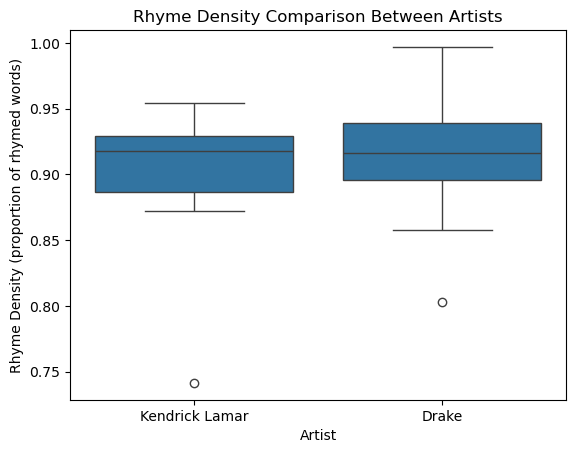

In [41]:
sb.boxplot(x="artist", y="rhyme_density", data=combined)
plt.title("Rhyme Density Comparison Between Artists")
plt.ylabel("Rhyme Density (proportion of rhymed words)")
plt.xlabel("Artist")
plt.show()

Both artists show very high rhyme density (Lots 0.9+). Drake’s median looks slightly higher, but both distributions overlap heavily. This shows rhyme use is consistently strong in both catalogs.

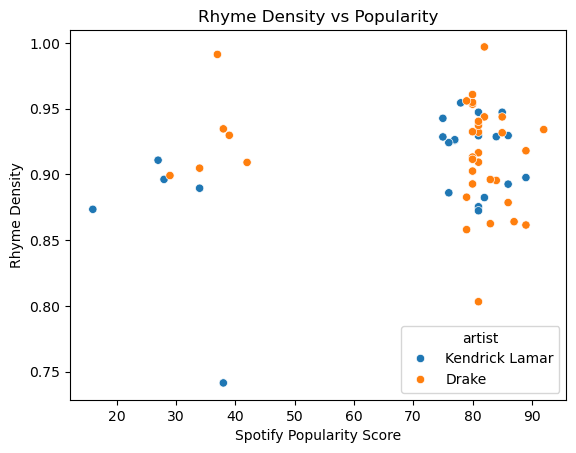

In [42]:
sb.scatterplot(x="popularity", y="rhyme_density", hue="artist", data=combined)
plt.title("Rhyme Density vs Popularity")
plt.xlabel("Spotify Popularity Score")
plt.ylabel("Rhyme Density")
plt.show()

Kendrick: +0.44 -> moderate positive correlation. This suggests his more lyrically complex tracks tend to be more popular. This aligns with his reputation for producing technically dense songs that still resonate well with his audience.

Drake: –0.29 -> weak negative correlation. This shows more rhyming or complex writing slightly correlates with lower popularity. Makes sense given Drake’s pop crossover appeal his simpler, melodic songs are usually the hits.

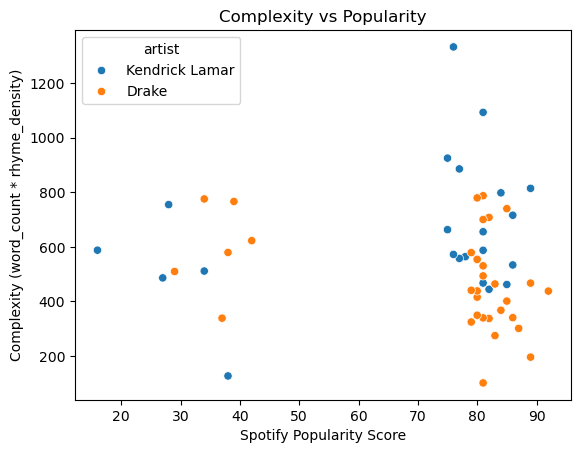

In [43]:
sb.scatterplot(x="popularity", y="complexity", hue="artist", data=combined)
plt.title("Complexity vs Popularity")
plt.xlabel("Spotify Popularity Score")
plt.ylabel("Complexity (word_count * rhyme_density)")
plt.show()

Correlation magnitudes are smaller (Kendrick +0.25, Drake –0.24). This implies rhyme density matters a bit more than total wordiness.

# Now lets look at the actual correlation numbers to double check findings

In [44]:
print("Kendrick: rhyme density vs popularity =", 
      kendrickStats["rhyme_density"].corr(kendrickStats["popularity"]))

print("Drake: rhyme density vs popularity =", 
      drakeStats["rhyme_density"].corr(drakeStats["popularity"]))

print("Kendrick: complexity vs popularity =", 
      kendrickStats["complexity"].corr(kendrickStats["popularity"]))

print("Drake: complexity vs popularity =", 
      drakeStats["complexity"].corr(drakeStats["popularity"]))

Kendrick: rhyme density vs popularity = 0.43626748634343915
Drake: rhyme density vs popularity = -0.15539574770524997
Kendrick: complexity vs popularity = 0.2870718851108495
Drake: complexity vs popularity = -0.31819599194826137


The data above suggests that Kendrick Lamar’s songs show a moderate positive relationship between lyrical density and popularity. This implies that his more lyrically intricate song-writing tends to perform well with the public. Drake, on the other hand, displays a mild negative correlation between rhyme complexity and popularity. This consistent with his broader pop appeal. Simpler and more melodic tracks dominate his top-performing songs. While both artists exhibit high overall rhyme density, the role of lyrical complexity in driving popularity appears more significant for Kendrick than for Drake.

# Thank you for viewing!

# _Little Bonus Analysis_

Since my question has a focus on each artists careers as a whole, I think it is fitting to view these stats across each year of their careers

In [45]:
combined["release_year"] = combined["release_date"].str[:4].astype(float) # Extract year
combined

,artist,artist_id,album_id,album_name,album_type,release_date,track_id,track_name,duration_ms,track_number,disc_number,explicit,popularity,lyrics,word_count,rhyme_density,complexity,release_year
0,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,5JjnoGJyOxfSZUZtk2rRwZ,Not Like Us,single,2024-05-04,6AI3ezQ4o3HUoP6Dhudph3,Not Like Us,274192,1,1,True,89,"Psst, I see dead people\n(\nMustard on the bea...",907,0.897577,814.102423,2024.0
1,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,7KXjTSCq5nL1LoYtL7XAwS,HUMBLE.,177000,8,1,True,86,Nobody pray for me\nIt been that day for me\nW...,598,0.892562,533.752066,2017.0
2,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,0aB0v4027ukVziUGwVGYpG,tv off (feat. lefty gunplay),220690,7,1,True,86,All I ever wanted was a black Grand National\n...,770,0.929504,715.718016,2024.0
3,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,6PGoSes0D9eUDeeAafB2As,LOVE. FEAT. ZACARI.,213400,10,1,False,85,"Maldición, amor o lujuria\nMaldición, todos no...",488,0.947242,462.254197,2017.0
4,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,2XPrwlaAHHXnJzP9tBcIzH,Swimming Pools (Drank),single,2012-01-01,6REbwUNlppTfcnV4d4ZoZi,Swimming Pools (Drank),247800,1,1,True,84,"Pour up (Drank), head shot (Drank)\nSit down (...",859,0.928654,797.713464,2012.0
5,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,6IZvVAP7VPPnsGX6bvgkqg,PRIDE.,275253,7,1,True,82,Love's gonna get you killed\nBut pride’s gonna...,504,0.882353,444.705882,2017.0
6,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,6HZILIRieu8S0iqY8kIKhj,DNA.,185946,2,1,True,81,"I got, I got, I got, I got—\nLoyalty, got roya...",671,0.875367,587.370968,2017.0
7,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,6PBZN8cbwkqm1ERj2BGXJ1,"good kid, m.A.A.d city",album,2012,2HbKqm4o0w5wEeEFXm2sD4,Money Trees,386906,5,1,True,81,"Uh, me and my niggas tryna get it, ya bish (Ya...",1153,0.947232,1092.158304,2012.0
8,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,0nj9Bq5sHDiTxSHunhgkFb,squabble up,157992,2,1,True,81,God knows\nI am reincarnated\nI was stargazin'...,536,0.872340,467.574468,2024.0
9,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,7ycBtnsMtyVbbwTfJwRjSP,To Pimp A Butterfly,album,2015-03-16,3iVcZ5G6tvkXZkZKlMpIUs,Alright,219333,7,1,True,81,"Alls my life, I has to fight, nigga\nAlls my l...",705,0.929379,655.211864,2015.0


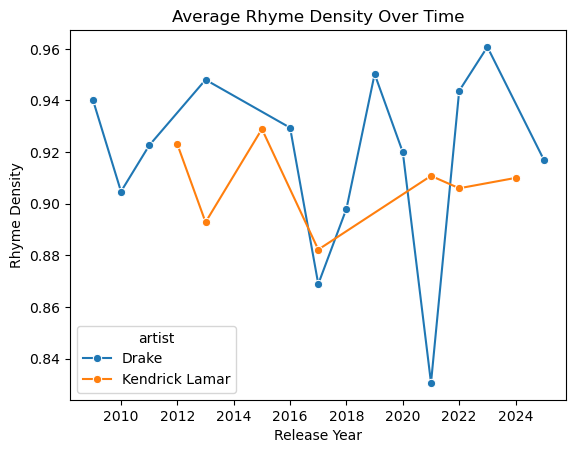

In [46]:
yearly = (combined.groupby(["artist", "release_year"])["rhyme_density"].mean().reset_index())
sb.lineplot(data=yearly, x="release_year", y="rhyme_density", hue="artist", marker="o")
plt.title("Average Rhyme Density Over Time")
plt.xlabel("Release Year")
plt.ylabel("Rhyme Density")
plt.show()

In [47]:
combined

,artist,artist_id,album_id,album_name,album_type,release_date,track_id,track_name,duration_ms,track_number,disc_number,explicit,popularity,lyrics,word_count,rhyme_density,complexity,release_year
0,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,5JjnoGJyOxfSZUZtk2rRwZ,Not Like Us,single,2024-05-04,6AI3ezQ4o3HUoP6Dhudph3,Not Like Us,274192,1,1,True,89,"Psst, I see dead people\n(\nMustard on the bea...",907,0.897577,814.102423,2024.0
1,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,7KXjTSCq5nL1LoYtL7XAwS,HUMBLE.,177000,8,1,True,86,Nobody pray for me\nIt been that day for me\nW...,598,0.892562,533.752066,2017.0
2,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,0aB0v4027ukVziUGwVGYpG,tv off (feat. lefty gunplay),220690,7,1,True,86,All I ever wanted was a black Grand National\n...,770,0.929504,715.718016,2024.0
3,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,6PGoSes0D9eUDeeAafB2As,LOVE. FEAT. ZACARI.,213400,10,1,False,85,"Maldición, amor o lujuria\nMaldición, todos no...",488,0.947242,462.254197,2017.0
4,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,2XPrwlaAHHXnJzP9tBcIzH,Swimming Pools (Drank),single,2012-01-01,6REbwUNlppTfcnV4d4ZoZi,Swimming Pools (Drank),247800,1,1,True,84,"Pour up (Drank), head shot (Drank)\nSit down (...",859,0.928654,797.713464,2012.0
5,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,6IZvVAP7VPPnsGX6bvgkqg,PRIDE.,275253,7,1,True,82,Love's gonna get you killed\nBut pride’s gonna...,504,0.882353,444.705882,2017.0
6,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,4eLPsYPBmXABThSJ821sqY,DAMN.,album,2017-04-14,6HZILIRieu8S0iqY8kIKhj,DNA.,185946,2,1,True,81,"I got, I got, I got, I got—\nLoyalty, got roya...",671,0.875367,587.370968,2017.0
7,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,6PBZN8cbwkqm1ERj2BGXJ1,"good kid, m.A.A.d city",album,2012,2HbKqm4o0w5wEeEFXm2sD4,Money Trees,386906,5,1,True,81,"Uh, me and my niggas tryna get it, ya bish (Ya...",1153,0.947232,1092.158304,2012.0
8,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,0hvT3yIEysuuvkK73vgdcW,GNX,album,2024-11-22,0nj9Bq5sHDiTxSHunhgkFb,squabble up,157992,2,1,True,81,God knows\nI am reincarnated\nI was stargazin'...,536,0.872340,467.574468,2024.0
9,Kendrick Lamar,2YZyLoL8N0Wb9xBt1NhZWg,7ycBtnsMtyVbbwTfJwRjSP,To Pimp A Butterfly,album,2015-03-16,3iVcZ5G6tvkXZkZKlMpIUs,Alright,219333,7,1,True,81,"Alls my life, I has to fight, nigga\nAlls my l...",705,0.929379,655.211864,2015.0


Both artists maintain pretty high levels of lyrical complexity throughout their careers. Drake’s rhyme density fluctuates more, suggesting variation across releases, while Kendrick Lamar’s appears more stable and slightly trends upward, reflecting more lyrical refinement over time.

In [48]:
combined['release_year'] = combined['release_year'].astype(int)

In [49]:
project2ReleaseYears = combined[['track_name', 'artist', 'release_year']]

In [50]:
project2ReleaseYears.to_csv('project2ReleaseYears.csv', index=False)